# Week 3: Data Preprocessing & Feature Engineering
### ML Internship Assignment — Uzma Fatima
**Program:** Machine Learning Internship | 8-Week Track
**Dataset:** Ames Housing + Titanic
**Tools:** Python, pandas, scikit-learn

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

## Loading the Datasets

 Loading the Ames Housing dataset using sklearn's fetch_openml function and the Titanic dataset from a public GitHub link. I will be using Ames for Task 1 and Task 5, and Titanic for Tasks 2, 3, and 4

In [48]:
# Loading Ames Housing dataset
from sklearn.datasets import fetch_openml

ames_data = fetch_openml(name='house_prices', as_frame=True, version=1, parser='auto')
ames = ames_data.frame.copy()

print("Ames Housing Dataset loaded!")
print("Shape:", ames.shape)
ames.head(3)

Ames Housing Dataset loaded!
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [49]:
# Loading Titanic dataset
titanic_raw = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic_raw.columns = titanic_raw.columns.str.lower()

print("Titanic Dataset loaded!")
print("Shape:", titanic_raw.shape)
titanic_raw.head()

Titanic Dataset loaded!
Shape: (891, 12)


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Task 1: Handle Missing Values in Ames Housing Dataset

First I want to understand how many missing values are there and which columns have them. In Ames Housing, some columns have NaN not because data is missing but because the house simply doesn't have that feature. For example PoolQC = NaN means the house has no pool, not that the value was forgotten.

So my plan is:
1. Fill those "feature absent" columns with the string "None"
2. For LotFrontage I will use the median of each Neighborhood because lot size depends on location
3. For other numeric columns like GarageYrBlt I will fill with 0 or median
4. At the end verify that no missing values remain

In [50]:
# Checking missing values in Ames dataset
missing = ames.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(ames) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Columns with missing values:")
missing_df.head(20)

Columns with missing values:


,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageFinish,81,5.55
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageType,81,5.55


In [51]:
# Making a working copy
ames_clean = ames.copy()

# These columns use NaN to mean "this feature doesn't exist in this house"
# So I will fill them with the string "None" instead of a real value
structural_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType', 'Electrical'
]

for col in structural_cols:
    if col in ames_clean.columns:
        ames_clean[col] = ames_clean[col].fillna('None')

print("Done filling structural NaN columns with 'None'")
print("Remaining missing values:", ames_clean.isnull().sum().sum())


Done filling structural NaN columns with 'None'
Remaining missing values: 348


In [52]:
# For LotFrontage I will use the median of each Neighborhood
# because lot size varies by area, so using the global median would not be accurate

if 'LotFrontage' in ames_clean.columns and 'Neighborhood' in ames_clean.columns:
    neighborhood_median = ames_clean.groupby('Neighborhood')['LotFrontage'].transform('median')
    ames_clean['LotFrontage'] = ames_clean['LotFrontage'].fillna(neighborhood_median)

    # If any are still missing fill with global median
    ames_clean['LotFrontage'] = ames_clean['LotFrontage'].fillna(ames_clean['LotFrontage'].median())

print("LotFrontage missing after imputation:", ames_clean['LotFrontage'].isnull().sum())

LotFrontage missing after imputation: 0


In [53]:
# GarageYrBlt and MasVnrArea - if no garage or veneer, area should be 0
zero_fill = ['GarageYrBlt', 'MasVnrArea', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']

for col in zero_fill:
    if col in ames_clean.columns:
        ames_clean[col] = ames_clean[col].fillna(0)

# Fill any remaining numeric columns with median
for col in ames_clean.select_dtypes(include=[np.number]).columns:
    if ames_clean[col].isnull().sum() > 0:
        ames_clean[col] = ames_clean[col].fillna(ames_clean[col].median())

# Fill any remaining object columns with mode
for col in ames_clean.select_dtypes(include='object').columns:
    if ames_clean[col].isnull().sum() > 0:
        ames_clean[col] = ames_clean[col].fillna(ames_clean[col].mode()[0])

print("Total missing values remaining:", ames_clean.isnull().sum().sum())

Total missing values remaining: 0


In [54]:
# Final check - should show 0 for all columns
print("Missing values after cleaning:")
print(ames_clean.isnull().sum().sum(), "total missing values")
print()
print("Shape of cleaned dataset:", ames_clean.shape)

Missing values after cleaning:
0 total missing values

Shape of cleaned dataset: (1460, 81)


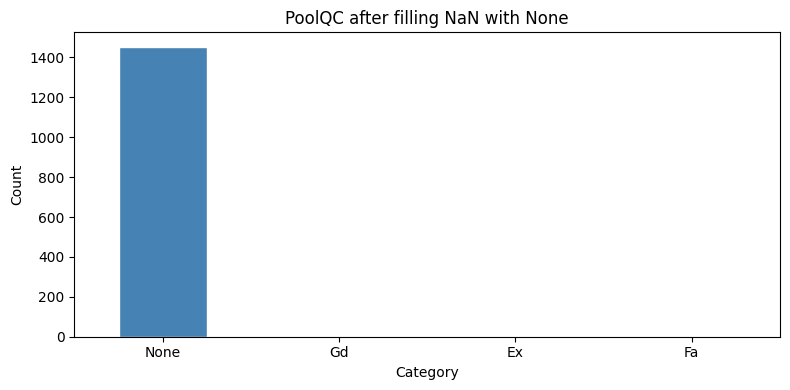

In [55]:
# Plotting PoolQC to see the 'None' category we created
plt.figure(figsize=(8, 4))
ames_clean['PoolQC'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('PoolQC after filling NaN with None')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 2: Feature Encoding (Titanic)

Now I will work on the Titanic dataset. Machine learning models can't work with text so I need to convert categorical columns to numbers.

- For the **sex** column I will use Label Encoding since there are only 2 values (male/female)
- For the **embarked** column I will use One-Hot Encoding since it has 3 categories with no order

In [56]:
# Making a copy and dropping columns I don't need
titanic = titanic_raw.copy()
titanic.drop(columns=['passengerid', 'name', 'ticket', 'cabin'], inplace=True)

# Filling missing values before encoding
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

print("Missing values after basic imputation:")
print(titanic.isnull().sum())

Missing values after basic imputation:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [57]:
# Label Encoding for sex column
# male = 0, female = 1
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])

# LabelEncoder gives female=0, male=1 alphabetically so I flip it
titanic['sex'] = titanic['sex'].map({0: 1, 1: 0})

print("Sex column after Label Encoding (0=male, 1=female):")
print(titanic['sex'].value_counts())

Sex column after Label Encoding (0=male, 1=female):
sex
0    577
1    314
Name: count, dtype: int64


In [58]:
# One-Hot Encoding for embarked column
titanic = pd.get_dummies(titanic, columns=['embarked'], prefix='embarked', dtype=int)

print("Columns after One-Hot Encoding:")
print(titanic.columns.tolist())
print()
print("First 5 rows:")
titanic.head()

Columns after One-Hot Encoding:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


---
## Task 3: Feature Scaling

Scaling is important because features like fare (range 0-500) will dominate features like parch (range 0-6) if we don't normalize them. I will apply both StandardScaler and MinMaxScaler to the 5 numeric features: age, fare, pclass, sibsp, parch.

In [59]:
# Selecting numeric features
numeric_features = ['age', 'fare', 'pclass', 'sibsp', 'parch']
X_numeric = titanic[numeric_features].copy()

print("Stats BEFORE scaling:")
X_numeric.describe().loc[['mean', 'std', 'min', 'max']]

Stats BEFORE scaling:


,age,fare,pclass,sibsp,parch
mean,29.361582,32.204208,2.308642,0.523008,0.381594
std,13.019697,49.693429,0.836071,1.102743,0.806057
min,0.420000,0.000000,1.000000,0.000000,0.000000
max,80.000000,512.329200,3.000000,8.000000,6.000000


In [60]:
# Applying StandardScaler
# This makes mean = 0 and std = 1 for each feature
ss = StandardScaler()
X_standard = pd.DataFrame(ss.fit_transform(X_numeric), columns=numeric_features)

print("Stats AFTER StandardScaler:")
X_standard.describe().loc[['mean', 'std', 'min', 'max']].round(4)

Stats AFTER StandardScaler:


,age,fare,pclass,sibsp,parch
mean,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0006,1.0006,1.0006,1.0006,1.0006
min,-2.2242,-0.6484,-1.5661,-0.4745,-0.4737
max,3.8916,9.6672,0.8274,6.7842,6.9741


In [61]:
# Applying MinMaxScaler
# This squeezes all values between 0 and 1
mms = MinMaxScaler()
X_minmax = pd.DataFrame(mms.fit_transform(X_numeric), columns=numeric_features)

print("Stats AFTER MinMaxScaler (min should be 0, max should be 1):")
X_minmax.describe().loc[['mean', 'std', 'min', 'max']].round(4)

Stats AFTER MinMaxScaler (min should be 0, max should be 1):


,age,fare,pclass,sibsp,parch
mean,0.3637,0.0629,0.6543,0.0654,0.0636
std,0.1636,0.0970,0.4180,0.1378,0.1343
min,0.0000,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,1.0000,1.0000,1.0000


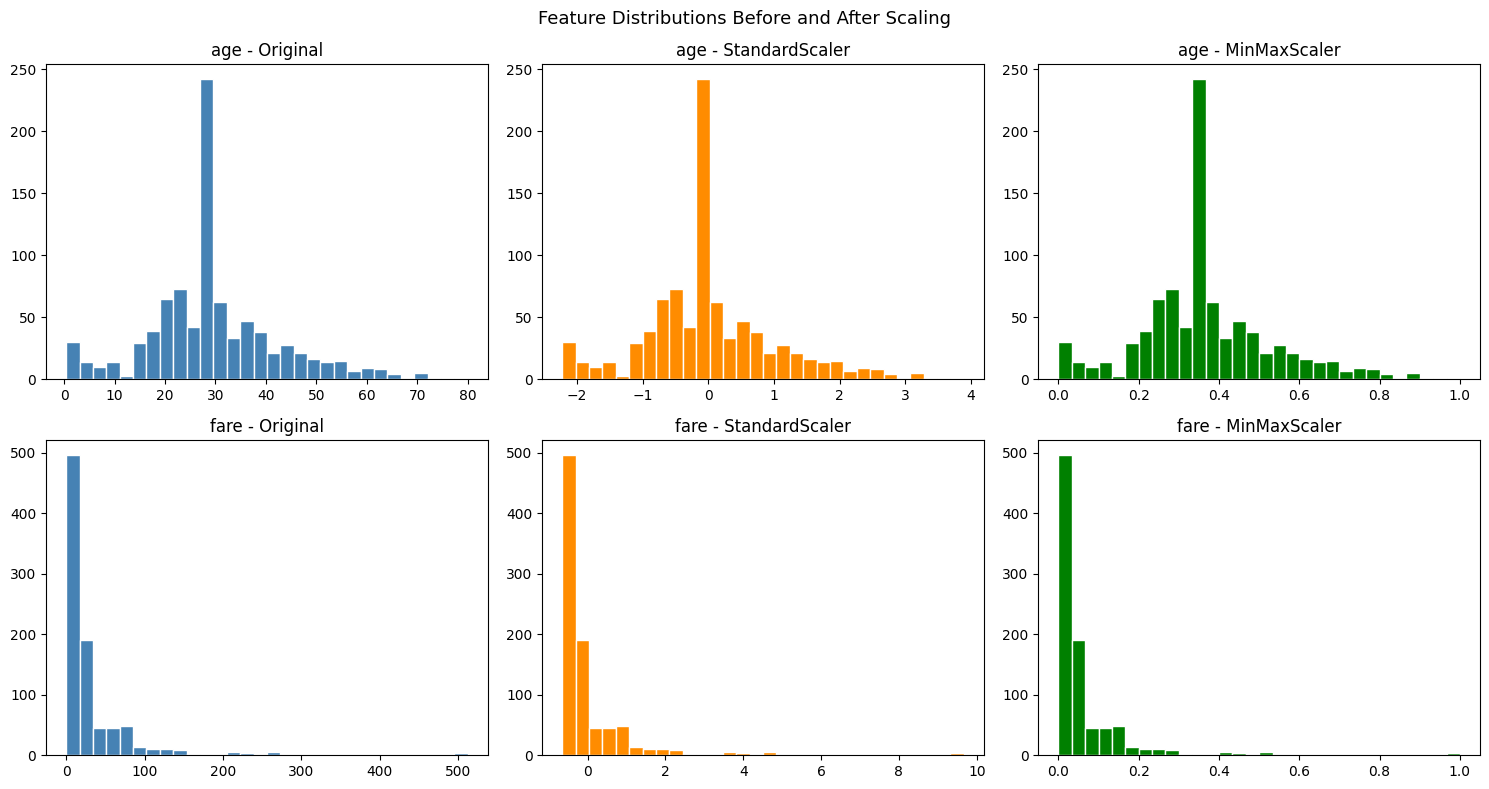

In [62]:
# Comparing distributions before and after scaling for 'age' and 'fare'
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feat in enumerate(['age', 'fare']):
    axes[i, 0].hist(X_numeric[feat], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{feat} - Original')

    axes[i, 1].hist(X_standard[feat], bins=30, color='darkorange', edgecolor='white')
    axes[i, 1].set_title(f'{feat} - StandardScaler')

    axes[i, 2].hist(X_minmax[feat], bins=30, color='green', edgecolor='white')
    axes[i, 2].set_title(f'{feat} - MinMaxScaler')

plt.suptitle('Feature Distributions Before and After Scaling', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 4: Train/Test Split

I need to split my data into training and testing sets. The model will learn from the training set and I will evaluate it on the test set. I am using 80% for training and 20% for testing. I also used stratify=y to make sure both splits have a similar proportion of survivors.

In [63]:
# Defining features and target
X = titanic.drop(columns=['survived'])
y = titanic['survived']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

X shape: (891, 9)
y shape: (891,)

Feature columns: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']


In [64]:
# Splitting into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes after split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shapes after split:
X_train: (712, 9)
X_test: (179, 9)
y_train: (712,)
y_test: (179,)


In [65]:
# Checking class balance in y_train
print("Class balance in y_train:")
print(y_train.value_counts(normalize=True).round(4))

Class balance in y_train:
survived
0    0.6166
1    0.3834
Name: proportion, dtype: float64


---
## Task 5: Build a scikit-learn Pipeline

A Pipeline lets me chain multiple steps together. Here I will chain SimpleImputer and StandardScaler. The most important rule is: I must fit the pipeline ONLY on the training data, then use it to transform the test data. If I fit on the full dataset, the model would "see" the test data during training which is called data leakage.

In [66]:
# Building the pipeline with SimpleImputer and StandardScaler
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

print("Pipeline created:")
print(preprocessing_pipeline)

Pipeline created:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [67]:
# Fitting pipeline on training data ONLY and transforming both sets
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)  # no fit here!

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print()
print("Missing values in processed train:", np.isnan(X_train_processed).sum())
print("Missing values in processed test:", np.isnan(X_test_processed).sum())

X_train_processed shape: (712, 9)
X_test_processed shape: (179, 9)

Missing values in processed train: 0
Missing values in processed test: 0


In [68]:
# Checking that train set has mean close to 0 and std close to 1
train_processed_df = pd.DataFrame(X_train_processed, columns=X_train.columns)

print("Mean of each feature after pipeline (should be close to 0):")
print(train_processed_df.mean().round(4))
print()
print("Std of each feature after pipeline (should be close to 1):")
print(train_processed_df.std().round(4))

Mean of each feature after pipeline (should be close to 0):
pclass       -0.0
sex           0.0
age           0.0
sibsp        -0.0
parch        -0.0
fare         -0.0
embarked_C   -0.0
embarked_Q   -0.0
embarked_S    0.0
dtype: float64

Std of each feature after pipeline (should be close to 1):
pclass        1.0007
sex           1.0007
age           1.0007
sibsp         1.0007
parch         1.0007
fare          1.0007
embarked_C    1.0007
embarked_Q    1.0007
embarked_S    1.0007
dtype: float64


In [69]:
# Saving the cleaned titanic dataset as required
titanic.to_csv('titanic_clean.csv', index=False)
print("titanic_clean.csv saved!")
print("Shape:", titanic.shape)

titanic_clean.csv saved!
Shape: (891, 10)
